In [145]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display
from PIL import Image

# =============================================================================
# CONFIGURATION
# =============================================================================
IMAGE_PATH_1 = "./input/bg1.jpg"
IMAGE_PATH_2 = "./input/bg2.jpg"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (400, 400)
FIG_DPI  = 150

# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def save_and_show(img_bgr, filename=None, title=""):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    
    if filename is not None:
        path = os.path.join(OUTPUT_DIR, filename)
        pil_img.save(path)
        print(f"[SAVED] {path}")
    
    if title:
        print(title)
    display(pil_img)


In [146]:
# =============================================================================
# A. TRANSLATION
# =============================================================================

def build_translation_matrix(tx, ty):
    """
    Ma tran dich chuyen trong toa do thuan nhat:
    [1 0 tx]
    [0 1 ty]
    [0 0  1]
    warpAffine nhan dang affine 2x3.
    """
    M = np.float32([[1, 0, tx],
                    [0, 1, ty]])
    return M


def demo_translation(img, tx=80, ty=50):
    H, W = img.shape[:2]
    M = build_translation_matrix(tx, ty)
    result = cv2.warpAffine(img, M, (W, H))
    return result, M


In [147]:
# =============================================================================
# B. ROTATION
# =============================================================================

def build_rotation_matrix(cx, cy, angle_deg, scale=1.0):
    """
    Xay dung ma tran xoay quanh tam (cx, cy) voi goc theta (do).
    R = T(cx,cy) * Rot(theta) * T(-cx,-cy)
    Dang affine 2x3:
    [cos(t)*s  -sin(t)*s  (1-s*cos)*cx + s*sin*cy]
    [sin(t)*s   cos(t)*s  -s*sin*cx + (1-s*cos)*cy]
    """
    theta = np.deg2rad(angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    s = scale
    M = np.float32([
        [ s*cos_t, -s*sin_t, (1 - s*cos_t)*cx + s*sin_t*cy],
        [ s*sin_t,  s*cos_t, -s*sin_t*cx + (1 - s*cos_t)*cy]
    ])
    return M


def demo_rotation(img, angle_deg=35):
    H, W = img.shape[:2]
    cx, cy = W / 2, H / 2
    M = build_rotation_matrix(cx, cy, angle_deg)
    result = cv2.warpAffine(img, M, (W, H))
    return result, M

In [148]:
# =============================================================================
# C. SCALING
# =============================================================================

def build_scaling_matrix(sx, sy, cx=0, cy=0):
    """
    Ma tran ti le quanh tam (cx, cy):
    [sx 0  cx*(1-sx)]
    [0  sy cy*(1-sy)]
    """
    M = np.float32([
        [sx, 0,  cx*(1 - sx)],
        [0,  sy, cy*(1 - sy)]
    ])
    return M


def demo_scaling(img, sx=0.6, sy=0.6):
    H, W = img.shape[:2]
    cx, cy = W / 2, H / 2
    M = build_scaling_matrix(sx, sy, cx, cy)
    result = cv2.warpAffine(img, M, (W, H))
    return result, M

In [149]:

def affine_from_points(img, src_pts, dst_pts):
    """
    img      : input image
    src_pts  : list/array 3 source points [[x1,y1],[x2,y2],[x3,y3]]
    dst_pts  : list/array 3 destination points

    Returns:
        img_src_drawn  (ảnh gốc có vẽ điểm)
        img_warp_drawn (ảnh sau affine có vẽ điểm)
        M (2x3 affine matrix)
    """

    src_pts = np.array(src_pts, dtype=np.float32)
    dst_pts = np.array(dst_pts, dtype=np.float32)

    if src_pts.shape != (3,2) or dst_pts.shape != (3,2):
        raise ValueError("Can dung chinh xac 3 diem SRC va 3 diem DST")

    # Tính affine matrix
    M = cv2.getAffineTransform(src_pts, dst_pts)

    h, w = img.shape[:2]
    warped = cv2.warpAffine(img, M, (w, h))

    # Vẽ điểm lên ảnh gốc
    img_src_drawn = img.copy()
    for pt in src_pts:
        cv2.circle(img_src_drawn, tuple(pt.astype(int)), 6, (0,255,0), -1)

    # Vẽ điểm lên ảnh sau affine
    img_warp_drawn = warped.copy()
    for pt in dst_pts:
        cv2.circle(img_warp_drawn, tuple(pt.astype(int)), 6, (0,0,255), -1)

    return img_src_drawn, img_warp_drawn, M

  Geometric Transformations – Computer Vision Demo
[SAVED] output\original.png
Original Image 1


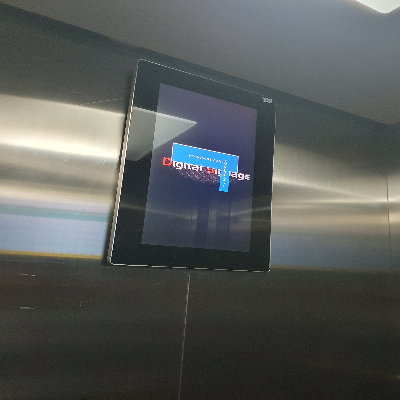

[SAVED] output\original_2.png
Original Image 2


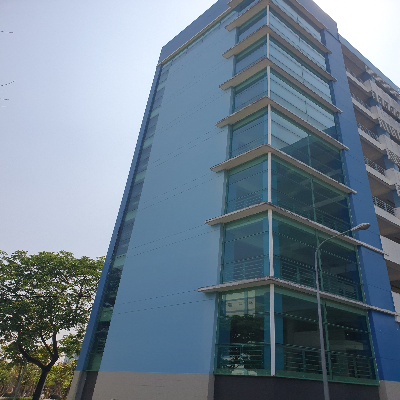

[SAVED] output\translation.png
Translation (tx=80, ty=50)


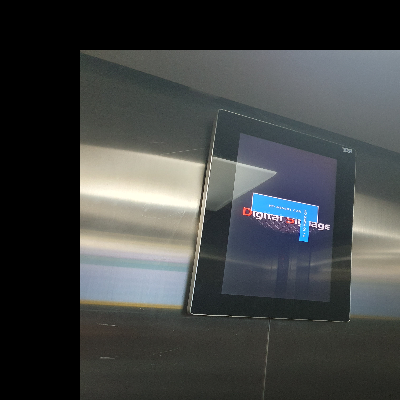


Translation Matrix (2x3):
[[ 1.  0. 80.]
 [ 0.  1. 50.]]
[SAVED] output\rotation.png
Rotation (35°, center)


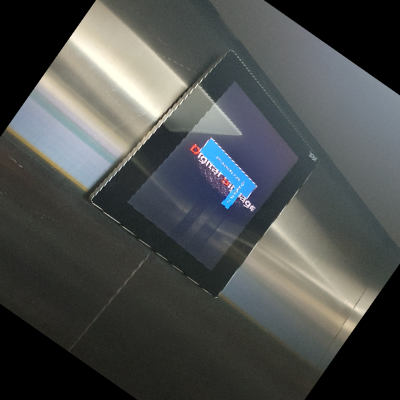


Rotation Matrix (2x3):
[[  0.81915206  -0.57357645 150.88487   ]
 [  0.57357645   0.81915206 -78.54569   ]]
[SAVED] output\scaling.png
Scaling (sx=sy=0.6)


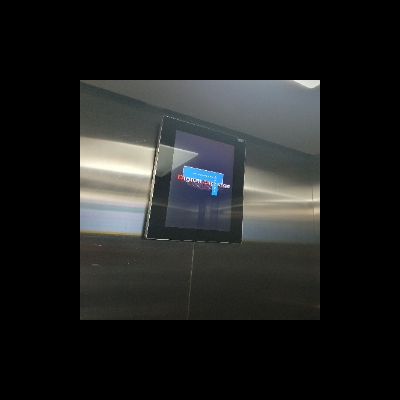


Scaling Matrix (2x3):
[[ 0.6  0.  80. ]
 [ 0.   0.6 80. ]]
[SAVED] output\affine_src.png
Source with Points 1


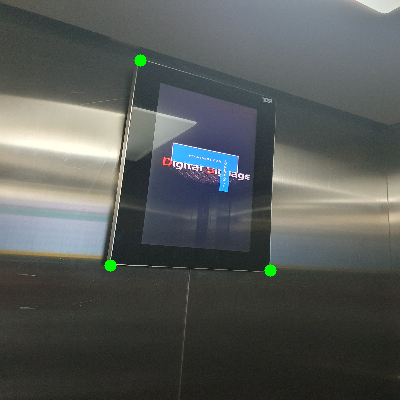

[SAVED] output\affine_result.png
Affine Result 1


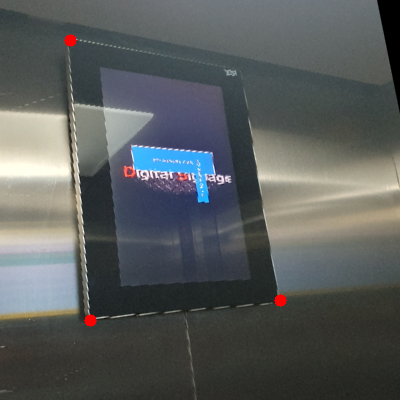


Affine Matrix (2x3):
[[   1.17905918    0.27010622 -111.27465857]
 [  -0.16691958    1.3414264   -17.1168437 ]]
[SAVED] output\affine_src_2.png
Source with Points 2


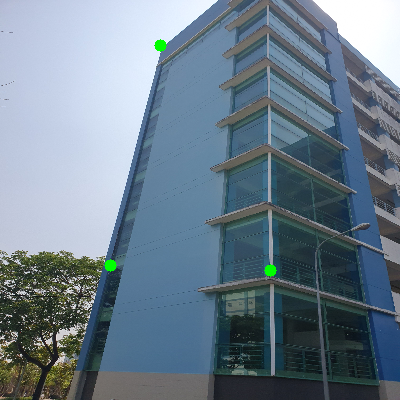

[SAVED] output\affine_result_2.png
Affine Result 2


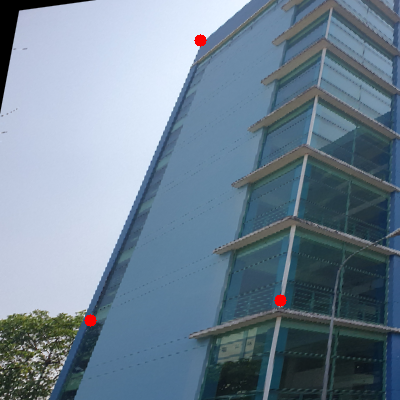


Affine Matrix (2x3):
[[ 1.19464034 -0.22849083 19.13963329]
 [-0.16361072  1.23554302 10.57827927]]
[SAVED] output\all_transforms.png

  Summary of Transformation Matrices
Translation : 2x3 affine, 2 DoF
Rotation    : 2x3 affine, 3 DoF (+ scale = similarity)
Scaling     : 2x3 affine, 2 DoF (anisotropic)

[DONE] All figures saved to ./figures/


In [150]:
# =============================================================================
# VISUALIZATION: ALL TRANSFORMATIONS
# =============================================================================

def visualize_all(original, results_dict):
    """Tong hop tat ca phep bien doi trong 1 figure."""
    titles = list(results_dict.keys())
    imgs   = list(results_dict.values())

    n = len(imgs) + 1
    cols = 3
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5), dpi=FIG_DPI)
    axes = axes.flatten()

    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    for i, (title, img) in enumerate(zip(titles, imgs), start=1):
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(title, fontsize=12, fontweight='bold')
        axes[i].axis('off')

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    fig.suptitle('Geometric Transformations – Computer Vision Demo',
                 fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, 'all_transforms.png')
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f"[SAVED] {path}")

# =============================================================================
# MAIN PIPELINE
# =============================================================================

def main():
    print("=" * 60)
    print("  Geometric Transformations – Computer Vision Demo")
    print("=" * 60)

    original_1 = cv2.imread(IMAGE_PATH_1)
    original_2 = cv2.imread(IMAGE_PATH_2)
    
    if original_1 is None:
        raise FileNotFoundError(f"Khong doc duoc anh: '{IMAGE_PATH_1}'. Kiem tra lai duong dan.")
    
    original_1 = cv2.resize(original_1, IMG_SIZE)   # chuan hoa kich thuoc
    original_2 = cv2.resize(original_2, IMG_SIZE)
    
    save_and_show(original_1, 'original.png', 'Original Image 1')
    save_and_show(original_2, 'original_2.png', 'Original Image 2')

    # 2. Translation
    trans_img, M_trans = demo_translation(original_1, tx=80, ty=50)
    save_and_show(trans_img, 'translation.png', f'Translation (tx=80, ty=50)')
    print(f"\nTranslation Matrix (2x3):\n{M_trans}")

    # 3. Rotation
    rot_img, M_rot = demo_rotation(original_1, angle_deg=35)
    save_and_show(rot_img, 'rotation.png', 'Rotation (35°, center)')
    print(f"\nRotation Matrix (2x3):\n{M_rot}")

    # 4. Scaling
    scale_img, M_scale = demo_scaling(original_1, sx=0.6, sy=0.6)
    save_and_show(scale_img, 'scaling.png', 'Scaling (sx=sy=0.6)')
    print(f"\nScaling Matrix (2x3):\n{M_scale}")
    
    # 5. Affine_1
    src_pts = [
        [140, 60],
        [270, 270],
        [110, 265]
    ]

    dst_pts = [
        [70, 40],
        [280, 300],
        [90, 320]
    ]

    img_src, img_affine, M_affine = affine_from_points(original_1, src_pts, dst_pts)

    save_and_show(img_src, "affine_src.png", "Source with Points 1")
    save_and_show(img_affine, "affine_result.png", "Affine Result 1")

    print(f"\nAffine Matrix (2x3):\n{M_affine}")
    
    # 5. Affine_2
    src_pts_2 = [
        [160, 45],
        [270, 270],
        [110, 265]
    ]

    dst_pts_2 = [
        [200, 40],
        [280, 300],
        [90, 320]
    ]

    img_src_2, img_affine_2, M_affine_2 = affine_from_points(original_2, src_pts_2, dst_pts_2)

    save_and_show(img_src_2, "affine_src_2.png", "Source with Points 2")
    save_and_show(img_affine_2, "affine_result_2.png", "Affine Result 2")

    print(f"\nAffine Matrix (2x3):\n{M_affine_2}")

    # 9. Tong hop hinh
    results = {
        'Translation':  trans_img,
        'Rotation':     rot_img,
        'Scaling':      scale_img,
        'Affine_Src_1':   img_src,
        'Affine_Dst_1':   img_affine,
        'Affine_Src_2':   img_src_2,
        'Affine_Dst_2':   img_affine_2
    }
    visualize_all(original_1, results)
    
    # 10. In bang tom tat
    print("\n" + "=" * 60)
    print("  Summary of Transformation Matrices")
    print("=" * 60)
    print(f"Translation : 2x3 affine, 2 DoF")
    print(f"Rotation    : 2x3 affine, 3 DoF (+ scale = similarity)")
    print(f"Scaling     : 2x3 affine, 2 DoF (anisotropic)")
    print("\n[DONE] All figures saved to ./figures/")

if __name__ == "__main__":
    main()